# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 01 — Backtester vectoriel (croisement de moyennes mobiles)

**Rôle de cette phase.** On construit le premier backtester, en version *vectorielle* (tout calculé d'un coup avec pandas). Objectif double :
1. maîtriser la mécanique fondamentale **signal → position → rendement → courbe d'équité** sur un cas simple ;
2. comprendre concrètement le piège n°1, le **look-ahead bias**, et comment le décalage `shift(1)` le neutralise.

C'est un échauffement volontairement simple. Le backtester vectoriel est parfait pour prototyper vite, mais il a des limites (pas de gestion fine des ordres, des coûts, du capital) qui motiveront le **moteur événementiel** de la Phase 2. On charge ici les données **déjà produites** par le notebook 00 : aucun retéléchargement.


## 0. Chargement des données figées

On lit `data/adj_close.csv` (cours ajustés) produit en Phase 0. Le notebook 00 a fait le travail de collecte une fois pour toutes ; on repart de ce fichier stable.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

adj = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)
print("Cours ajustés chargés :", adj.shape)
print("Actifs :", list(adj.columns))
print(f"Période : {adj.index.min().date()} -> {adj.index.max().date()}")
adj.tail(3)

Cours ajustés chargés : (4177, 11)
Actifs : ['AAPL', 'AMZN', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'PEP', 'PG', 'SPY', 'XOM']
Période : 2010-01-04 -> 2026-08-12


,AAPL,AMZN,JNJ,JPM,KO,MSFT,NVDA,PEP,PG,SPY,XOM
Date,,,,,,,,,,,
2026-08-10,308.260010,278.089996,261.809998,359.790009,86.870003,506.059998,217.550003,137.729996,146.440002,773.030029,159.789993
2026-08-11,304.910004,272.269989,259.799988,362.040009,86.480003,503.809998,217.500000,138.410004,145.210007,770.559998,159.800003
2026-08-12,301.820007,268.730011,261.040009,365.744995,86.834999,494.180115,222.520004,138.690002,144.558304,772.909973,159.595001


## 1. La stratégie : croisement de moyennes mobiles (SMA crossover)

C'est la stratégie de suivi de tendance la plus classique. On calcule deux moyennes mobiles simples des cours :
- une **moyenne courte** (réactive, ex. 50 jours) qui suit la tendance récente ;
- une **moyenne longue** (lente, ex. 200 jours) qui représente la tendance de fond.

**La règle :**
- quand la moyenne courte passe **au-dessus** de la longue (le *golden cross*), on considère que la tendance est haussière → on se met **long** (position = 1) ;
- quand la courte repasse **en dessous** (le *death cross*), on **sort** → position neutre (0).

On adopte une logique **long / flat** (on est soit investi, soit à l'écart), simple et réaliste pour un premier backtest. La variante **long / short** (position = −1 au lieu de 0 dans les phases baissières) est une extension naturelle qu'on pourra tester ensuite.

On illustre d'abord sur un titre bien tendanciel, AAPL, avec les fenêtres classiques 50 / 200.


C:\Users\abeli\AppData\Local\Temp\ipykernel_31396\3842925721.py:16: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(px.index[cross == 1],  px[cross == 1],  "^", color="green", ms=9, label="Golden cross (achat)")


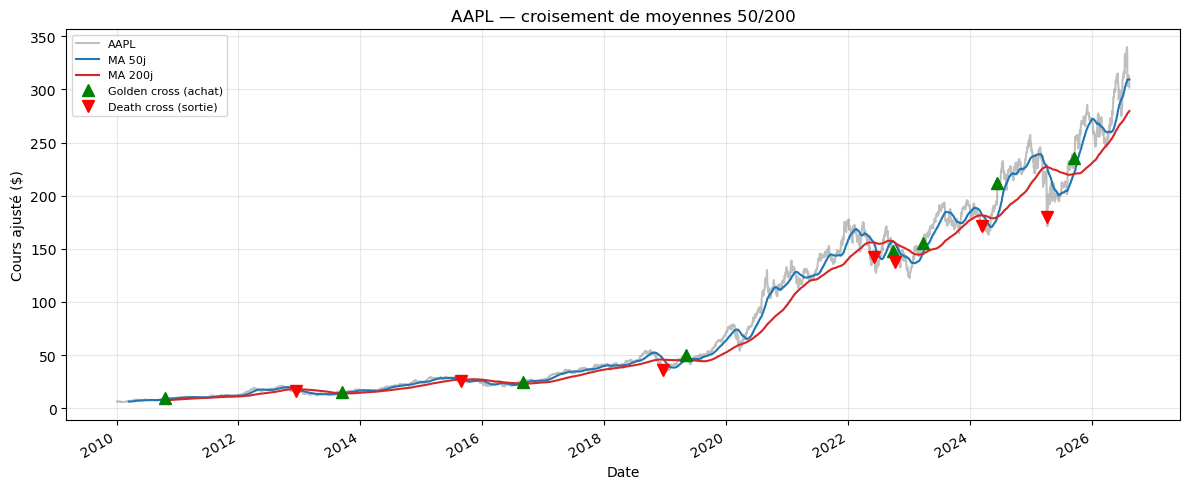

In [2]:
TICKER = "AAPL"
SHORT, LONG = 50, 200

px = adj[TICKER]
ma_s = px.rolling(SHORT).mean()
ma_l = px.rolling(LONG).mean()

fig, ax = plt.subplots(figsize=(12, 5))
px.plot(ax=ax, label=TICKER, alpha=0.5, color="gray")
ma_s.plot(ax=ax, label=f"MA {SHORT}j", color="tab:blue")
ma_l.plot(ax=ax, label=f"MA {LONG}j", color="tab:red")

# Marqueurs des croisements
signal = (ma_s > ma_l).astype(int)
cross = signal.diff()
ax.plot(px.index[cross == 1],  px[cross == 1],  "^", color="green", ms=9, label="Golden cross (achat)")
ax.plot(px.index[cross == -1], px[cross == -1], "v", color="red",   ms=9, label="Death cross (sortie)")
ax.set_title(f"{TICKER} — croisement de moyennes {SHORT}/{LONG}")
ax.set_ylabel("Cours ajusté ($)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. Signal → position : la règle du `shift(1)` (le point crucial)

Le **signal** du jour $t$ se calcule avec les moyennes mobiles, donc avec le cours de clôture **du jour $t$**. Mais ce cours n'est connu **qu'à la fin** du jour $t$. On ne peut donc pas trader *pendant* le jour $t$ sur une information disponible seulement à sa clôture.

La règle correcte : **la position détenue le jour $t$ est décidée à partir du signal de la veille**. En pratique, on décale le signal d'un cran :

$$\text{position}_t = \text{signal}_{t-1}$$

C'est exactement ce que fait `signal.shift(1)`. Sans ce décalage, on utiliserait le signal du jour $t$ (basé sur le cours de clôture de $t$) pour capter le rendement du jour $t$ : on « saurait » la clôture avant qu'elle n'arrive. C'est le **look-ahead bias**, l'erreur qui gonfle artificiellement les performances. On le démontrera chiffres à l'appui en section 5.


In [3]:
position = signal.shift(1)   # décision d'hier appliquée aujourd'hui
compare = pd.DataFrame({
    "MA_courte": ma_s, "MA_longue": ma_l,
    "signal (jour t)": signal, "position (= signal t-1)": position
}).dropna()
compare.tail(6)

,MA_courte,MA_longue,signal (jour t),position (= signal t-1)
Date,,,,
2026-08-05,309.387372,278.327936,1,1.0
2026-08-06,309.468903,278.631833,1,1.0
2026-08-07,309.518459,278.890759,1,1.0
2026-08-10,309.438845,279.123044,1,1.0
2026-08-11,309.301223,279.360100,1,1.0
2026-08-12,309.216702,279.576077,1,1.0


## 3. Rendement de la stratégie et courbe d'équité

Le rendement de la stratégie un jour donné est le rendement de l'actif **si on était investi ce jour-là**, zéro sinon :

$$r^{\text{strat}}_t = \text{position}_t \times r^{\text{actif}}_t$$

La **courbe d'équité** est la valeur cumulée d'un capital initial de 1, en composant les rendements journaliers : $(1 + r^{\text{strat}})$ multipliés dans le temps. On la compare systématiquement au **buy & hold** (rester investi en permanence), qui est la référence honnête : battre le simple fait de détenir l'actif n'a rien d'évident.


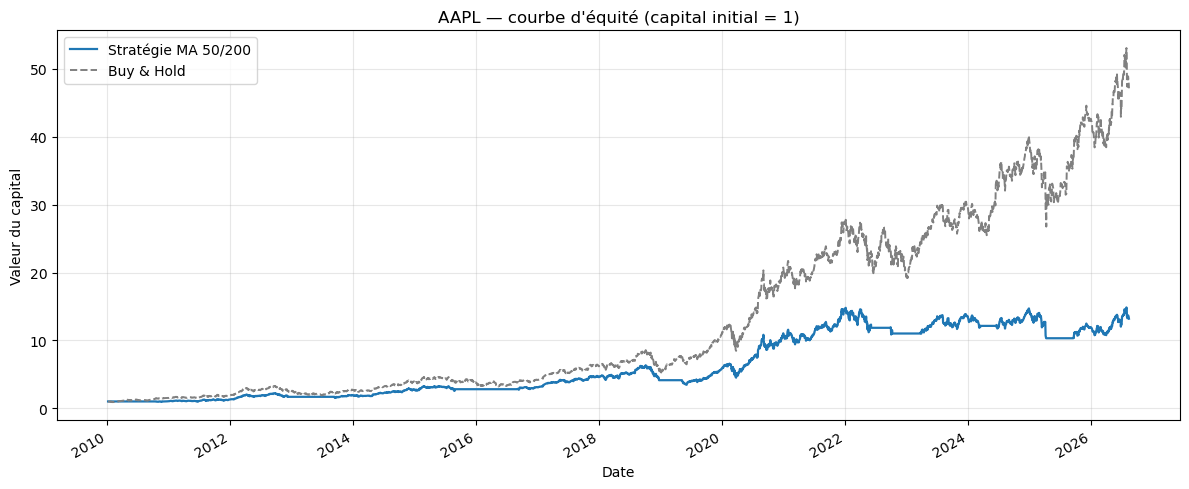

In [4]:
def ma_crossover_backtest(price, short=50, long=200):
    df = pd.DataFrame({"price": price})
    df["ma_s"] = df["price"].rolling(short).mean()
    df["ma_l"] = df["price"].rolling(long).mean()
    df["signal"] = np.where(df["ma_s"] > df["ma_l"], 1.0, 0.0)   # long / flat
    df["position"] = df["signal"].shift(1)                        # anti look-ahead
    df["asset_ret"] = df["price"].pct_change()
    df["strat_ret"] = df["position"] * df["asset_ret"]
    df = df.dropna(subset=["position", "asset_ret"])
    df["equity"]    = (1 + df["strat_ret"]).cumprod()
    df["bh_equity"] = (1 + df["asset_ret"]).cumprod()
    return df

res = ma_crossover_backtest(px, SHORT, LONG)

fig, ax = plt.subplots(figsize=(12, 5))
res["equity"].plot(ax=ax, label=f"Stratégie MA {SHORT}/{LONG}", color="tab:blue", lw=1.6)
res["bh_equity"].plot(ax=ax, label="Buy & Hold", color="gray", ls="--", lw=1.4)
ax.set_title(f"{TICKER} — courbe d'équité (capital initial = 1)")
ax.set_ylabel("Valeur du capital"); ax.legend(); plt.tight_layout(); plt.show()

## 4. Mesures de performance

On résume la stratégie par les mesures standard. Les rendements journaliers sont **annualisés** avec 252 jours de bourse. On suppose un taux sans risque nul (hypothèse simplificatrice, on l'assumera dans le rapport).

- **Rendement total** et **CAGR** (rendement annualisé composé) : la performance.
- **Volatilité annualisée** : le risque, mesuré par l'écart-type des rendements.
- **Sharpe** : rendement par unité de risque total. La mesure reine.
- **Sortino** : comme Sharpe mais ne pénalise que la volatilité *à la baisse* (plus juste, car la volatilité haussière n'est pas un risque).
- **Max drawdown** : la pire perte du sommet au creux. Mesure la douleur maximale subie.
- **Calmar** : CAGR rapporté au max drawdown. Rendement par unité de perte extrême.
- **Exposition** : fraction du temps réellement investi (une stratégie long/flat n'est pas toujours sur le marché).


In [5]:
def perf_metrics(ret, equity, ann=252, rf=0.0):
    ret = ret.dropna()
    n = len(ret); years = n / ann
    total  = equity.iloc[-1] / equity.iloc[0] - 1
    cagr   = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1
    vol    = ret.std() * np.sqrt(ann)
    sharpe = (ret.mean() * ann - rf) / (ret.std() * np.sqrt(ann)) if ret.std() > 0 else np.nan
    downside = ret[ret < 0].std() * np.sqrt(ann)
    sortino  = (ret.mean() * ann - rf) / downside if downside > 0 else np.nan
    dd = equity / equity.cummax() - 1
    maxdd = dd.min()
    calmar = cagr / abs(maxdd) if maxdd < 0 else np.nan
    exposure = (ret != 0).mean()
    return {"Rendement total": total, "CAGR": cagr, "Volatilité": vol,
            "Sharpe": sharpe, "Sortino": sortino, "Max drawdown": maxdd,
            "Calmar": calmar, "Exposition": exposure}

tbl = pd.DataFrame({
    f"Stratégie MA {SHORT}/{LONG}": perf_metrics(res["strat_ret"], res["equity"]),
    "Buy & Hold": perf_metrics(res["asset_ret"], res["bh_equity"]),
})
tbl.round(4)

,Stratégie MA 50/200,Buy & Hold
Rendement total,12.2001,46.0709
CAGR,0.1685,0.2617
Volatilité,0.2353,0.2815
Sharpe,0.7798,0.9670
Sortino,0.9106,1.3471
Max drawdown,-0.4561,-0.4380
Calmar,0.3694,0.5974
Exposition,0.7364,0.9983


### Drawdown dans le temps (underwater plot)
Le graphe *underwater* montre à chaque instant la distance au dernier sommet. Il rend visible la profondeur **et la durée** des pertes, ce que le seul chiffre du max drawdown ne dit pas.


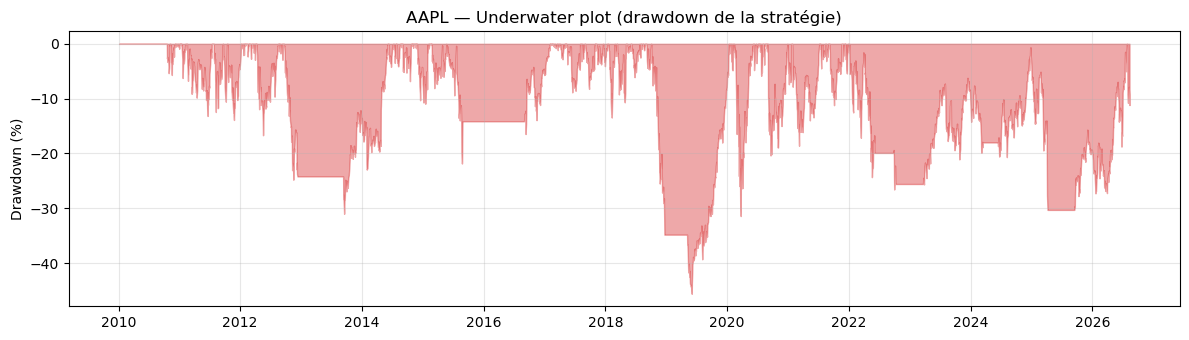

In [6]:
dd = res["equity"] / res["equity"].cummax() - 1
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(dd.index, dd.values * 100, 0, color="tab:red", alpha=0.4)
ax.set_title(f"{TICKER} — Underwater plot (drawdown de la stratégie)")
ax.set_ylabel("Drawdown (%)"); plt.tight_layout(); plt.show()

## 5. Démonstration du look-ahead bias

On refait le calcul **sans** le `shift(1)** : la position du jour $t$ utilise le signal du jour $t$ (donc le cours de clôture de $t$) pour capter le rendement de $t$. C'est de la triche. On compare la courbe d'équité et le Sharpe des deux versions.

> Sur des cours réels tendanciels, l'écart peut être important. Retiens le principe : une performance qui « brille » peut simplement provenir d'un look-ahead bias caché. C'est la première chose à vérifier devant un backtest trop beau.


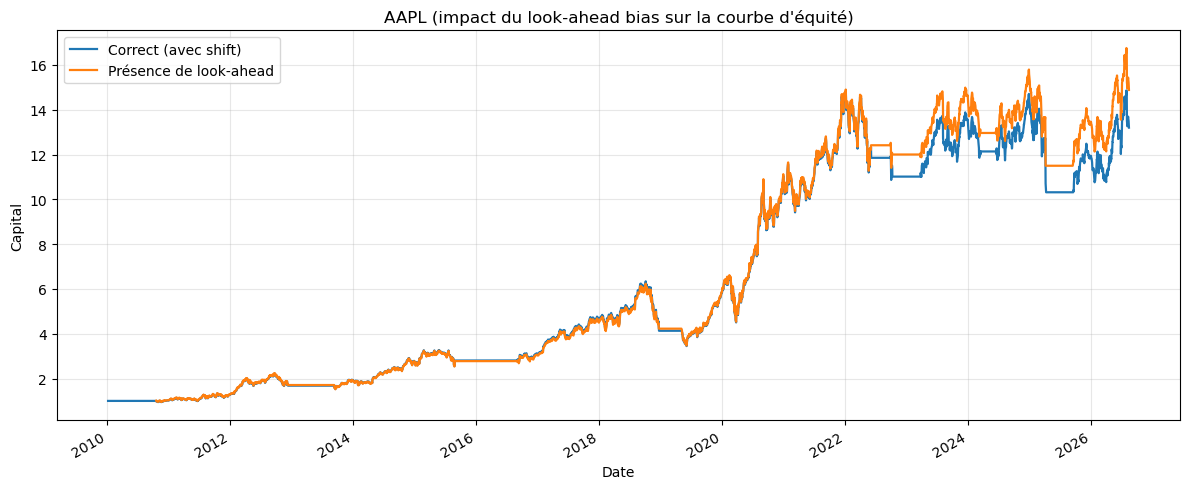

Sharpe correct (avec shift) : 0.780
Sharpe triche (sans shift)  : 0.832
Surestimation artificielle  : 0.052 de Sharpe


In [7]:
# Version correcte (déjà calculée) vs version tricheuse (sans shift)
cheat = pd.DataFrame({"price": px})
cheat["ma_s"] = cheat["price"].rolling(SHORT).mean()
cheat["ma_l"] = cheat["price"].rolling(LONG).mean()
cheat["signal"] = np.where(cheat["ma_s"] > cheat["ma_l"], 1.0, 0.0)
cheat["asset_ret"] = cheat["price"].pct_change()
cheat["strat_ret"] = cheat["signal"] * cheat["asset_ret"]     # PAS de shift = look-ahead
cheat = cheat.dropna()
cheat["equity"] = (1 + cheat["strat_ret"]).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
res["equity"].plot(ax=ax, label="Correct (avec shift)", color="tab:blue", lw=1.6)
cheat["equity"].plot(ax=ax, label="Présence de look-ahead", color="tab:orange", lw=1.6)
ax.set_title(f"{TICKER} (impact du look-ahead bias sur la courbe d'équité)")
ax.set_ylabel("Capital"); ax.legend(); plt.tight_layout(); plt.show()

sh_ok = perf_metrics(res["strat_ret"], res["equity"])["Sharpe"]
sh_cheat = (cheat["strat_ret"].mean()*252)/(cheat["strat_ret"].std()*np.sqrt(252))
print(f"Sharpe correct (avec shift) : {sh_ok:.3f}")
print(f"Sharpe triche (sans shift)  : {sh_cheat:.3f}")
print(f"Surestimation artificielle  : {(sh_cheat - sh_ok):.3f} de Sharpe")

## 6. La stratégie sur tout l'univers momentum

Un backtest sur un seul titre est anecdotique. On applique la même règle 50/200 à chacune des 8 valeurs de l'univers momentum et on compare les Sharpe. L'objectif n'est pas encore d'optimiser, mais de voir si le suivi de tendance tient debout **en moyenne**, au-delà d'un titre chanceux.


In [8]:
MOMENTUM_UNIVERSE = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "XOM", "JNJ", "PG"]

rows = []
for t in MOMENTUM_UNIVERSE:
    r = ma_crossover_backtest(adj[t], SHORT, LONG)
    m_strat = perf_metrics(r["strat_ret"], r["equity"])
    m_bh    = perf_metrics(r["asset_ret"], r["bh_equity"])
    rows.append({
        "Ticker": t,
        "CAGR strat": m_strat["CAGR"], "Sharpe strat": m_strat["Sharpe"],
        "MaxDD strat": m_strat["Max drawdown"],
        "Sharpe B&H": m_bh["Sharpe"], "CAGR B&H": m_bh["CAGR"],
    })

summary = pd.DataFrame(rows).set_index("Ticker")
print("Sharpe moyen stratégie :", round(summary["Sharpe strat"].mean(), 3),
      "| Sharpe moyen B&H :", round(summary["Sharpe B&H"].mean(), 3))
summary.round(3)

Sharpe moyen stratégie : 0.646 | Sharpe moyen B&H : 0.773


,CAGR strat,Sharpe strat,MaxDD strat,Sharpe B&H,CAGR B&H
Ticker,,,,,
AAPL,0.168,0.780,-0.456,0.967,0.262
MSFT,0.158,0.789,-0.280,0.840,0.203
NVDA,0.451,1.175,-0.566,1.058,0.458
AMZN,0.147,0.647,-0.428,0.840,0.249
JPM,0.114,0.625,-0.436,0.701,0.166
XOM,0.060,0.424,-0.419,0.475,0.091
JNJ,0.055,0.436,-0.470,0.750,0.121
PG,0.033,0.294,-0.232,0.554,0.085


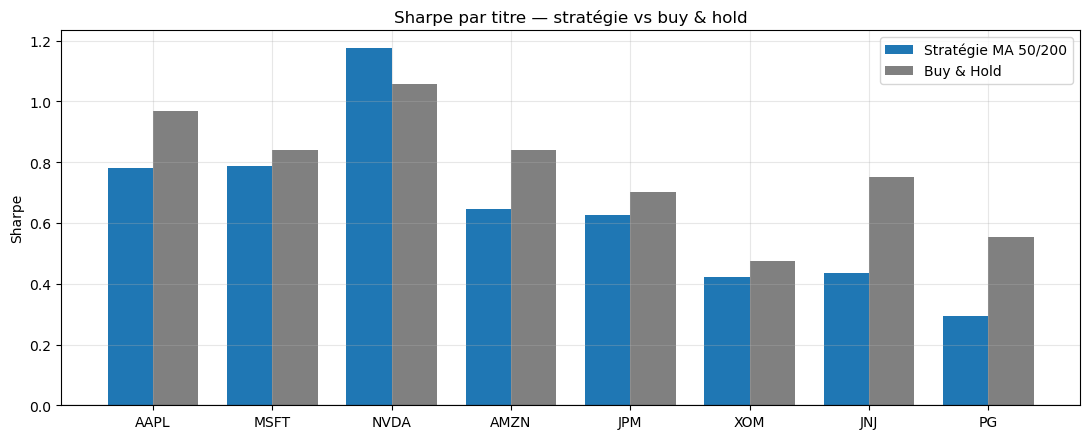

In [9]:
# Visualisation : Sharpe stratégie vs buy & hold par titre
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(summary)); w = 0.38
ax.bar(x - w/2, summary["Sharpe strat"], w, label="Stratégie MA 50/200", color="tab:blue")
ax.bar(x + w/2, summary["Sharpe B&H"],  w, label="Buy & Hold", color="gray")
ax.set_xticks(x); ax.set_xticklabels(summary.index)
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("Sharpe")
ax.set_title("Sharpe par titre — stratégie vs buy & hold")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Limites du backtester vectoriel (ce qui motive la Phase 2)

Ce backtester est utile mais naïf. Ses limites principales :

- **Pas de coûts de transaction ni de slippage.** Chaque croisement déclenche un aller-retour qui, en réalité, coûte. On l'ajoutera en Phase 3.
- **Pas de gestion réaliste du capital ni du dimensionnement.** On suppose qu'on investit « tout ou rien », sans contrainte de taille de position ni de trésorerie.
- **Difficile d'éviter subtilement le look-ahead** sur des logiques plus complexes : dès que la décision dépend de l'état du portefeuille, l'approche vectorielle devient fragile.
- **Pas de séparation des responsabilités** (données, stratégie, portefeuille, exécution mélangés dans un même DataFrame), donc peu réutilisable.

La Phase 2 répond à tout cela avec un **moteur événementiel** : des objets `DataHandler`, `Strategy`, `Portfolio`, `ExecutionHandler` qui rejouent l'histoire pas à pas et communiquent par une file d'événements. C'est plus lourd, mais fidèle à la réalité et modulaire (le moteur resservira au Projet 5).

**Prochaine étape — Phase 2 : le moteur événementiel.**
